In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [6]:
conn=sqlite3.connect("customer_churn.db")

sql_query="""
            SELECT name
            From sqlite_master
            Where type="table"
"""
tables=pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created Dataframe:df_{table_name}")
conn.close()

Created Dataframe:df_db_customer
Created Dataframe:df_db_subscription
Created Dataframe:df_db_support


In [7]:
#for printing table name and column name

conn=sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"/nTable Name:{table_name}")
    columns_query=f"PRAGMA table_info({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()

/nTable Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']
/nTable Name:db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']
/nTable Name:db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [8]:
df_db_customer.head() 

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
df_db_customer.tail() 

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [10]:
df_db_customer.shape

(21, 8)

In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [12]:
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

In [13]:
df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [14]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [15]:
df_db_customer["dob"]=pd.to_datetime(df_db_customer["dob"])

In [16]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [17]:
df_db_customer.replace({'Men':"Male",'Women':"Female"},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [18]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [20]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [21]:
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [22]:
df_db_customer['country']

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [23]:
df_db_subscription['cancellation_reason'].head()

0                      None
1    Switched to competitor
2                      None
3                      None
4             Too expensive
Name: cancellation_reason, dtype: object

In [24]:
date_col=['subscription_start_date','cancellation_date','renewal_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [25]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [26]:
df_db_subscription.head(10)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0


In [27]:
#first fix table then merge
df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left')
                .merge(df_db_support,on='customerid',how='left'))

In [28]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,col_1,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,N,60.0,None,service issue
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,Y,10.0,None,demaned refund
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN,NaN


In [29]:
df.shape

(23, 22)

In [30]:
df_db_subscription.shape






(21, 12)

In [31]:
df_db_support['complaint_count']=df_db_support.groupby("customerid")['customerid'].transform('count')

In [32]:
df_db_support=df_db_support.sort_values('complaint_count').drop_duplicates('customerid',keep="last")

In [33]:
df_db_support['customerid'].size

7

In [34]:
df=(df_db_subscription
   .merge(df_db_customer,on='customerid',how='left')
   .merge(df_db_support,on='customerid',how='left'))

In [35]:
df.shape

(21, 23)

In [36]:
#Data analysis

In [37]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment',
       'complaint_count'],
      dtype='object')

In [38]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment', 'complaint_count']


In [39]:
print(df_db_customer.columns)
print(df_db_support.columns)

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob'], dtype='object')
Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment', 'complaint_count'],
      dtype='object')


In [40]:
print(df.shape)
print(df.columns)

(21, 23)
Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment',
       'complaint_count'],
      dtype='object')


In [41]:
print(df_db_subscription.columns)

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag'],
      dtype='object')


In [42]:
df_db_subscription['churn_flag'] = np.where(
    df_db_subscription['cancellation_date'].notna(), 1, 0
)

In [43]:
print(df_db_subscription.columns)

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag'],
      dtype='object')


In [44]:
print('churn_flag' in df.columns)

True


In [45]:
df = (
    df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left')
)

In [46]:
df["churn_flag"].mean()

np.float64(0.2857142857142857)

In [47]:
churn_rate=df_db_subscription["churn_flag"].mean()*100
print("churn_rate= ",round(churn_rate,2),"%")

churn_rate=  28.57 %


In [48]:
retention_rate=100-churn_rate
print("retention_rate= ",round(retention_rate,2),"%")

retention_rate=  71.43 %


In [49]:
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [50]:
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name="churn_rate_pct"))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [51]:
#Arpu
arpu=(df['monthly_charges'].mean())
print('Arpu= ',round(arpu,2))

Arpu=  18.85


In [52]:
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'])
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'])

In [53]:
#avg tenure date user has had
#count of days user has used in btw start and end and user didnt cancel then replace with thte todays date

today=pd.Timestamp.today()

df['tenure_days']=np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,col_1,comment,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,NaN,NaN,1960.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,Y,10.0,None,demaned refund,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN,NaN,NaN,1345.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN,NaN,NaN,2635.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20 00:00:00,Y,20.0,None,None,1.0,419.0


In [54]:
avg_tenure=df['tenure_days'].mean()
print(avg_tenure)

1503.7142857142858


In [55]:
#revenue at risk
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print(revenue_at_risk)

73.94


In [56]:
df["escalations"].unique()

array([nan, 'Y', 'N'], dtype=object)

In [57]:
esclation_rate=(df["escalations"] == 'Y').mean()*100
print("Escalation Rate=",round(esclation_rate,2),"%")

Escalation Rate= 19.05 %


In [58]:
#Avg complaint rate
avg_complaint=(df['complaint_count'].sum()/df["customerid"].nunique())
print("Avg complaint by user=",round(avg_complaint,2))

Avg complaint by user= 0.43


In [59]:
corr_df=df[['escalations','churn_flag']].dropna()

#corr_df=df['escalations']=np.where(df['escalations']=='Y',1,0)
#df['escalations']

correlation=corr_df['escalations'].corr(df['churn_flag'])
print("Coorelation btw esclations and churn_flag is = ",round(correlation,2))

ValueError: could not convert string to float: 'Y'

In [ ]:
print(corr_df.dtypes)

In [ ]:
print(df['escalations'].value_counts())
print(df['churn_flag'].value_counts())

In [ ]:
print(df_db_support['escalations'].unique())

In [ ]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)

In [ ]:
print(df_db_support['escalations'].unique())

In [ ]:
print(df['escalations'].unique())
print(df['escalations'].value_counts(dropna=False))

In [ ]:
print(df_db_support['escalations'].value_counts())

print(df_db_support['escalations'].unique())

In [ ]:
# Check just after the merge
df = (
    df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left')
)

print(df['escalations'].unique())
print(df['escalations'].value_counts(dropna=False))

In [70]:
corr_df=df[['escalations','churn_flag']].dropna()

#corr_df=df['escalations']=np.where(df['escalations']=='Y',1,0)
df['escalations']

correlation=corr_df['escalations'].corr(df['churn_flag'])
print("Coorelation btw esclations and churn_flag is = ",round(correlation,2))

Coorelation btw esclations and churn_flag is =  nan


C:\Users\hp\softprogram\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\hp\softprogram\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [65]:
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices=['low','med','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')
df[['churn_score', 'churn_risk']].head(10)

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high
5,22,low
6,79,high
7,5,low
8,34,low
9,41,low


In [ ]:
#Data Visulaisastion

In [66]:
df_visual=df.copy()

In [67]:
df_visual.shape

(21, 25)

In [68]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment',
       'complaint_count', 'tenure_days', 'churn_risk'],
      dtype='object')

In [69]:
#Monthly churn trend

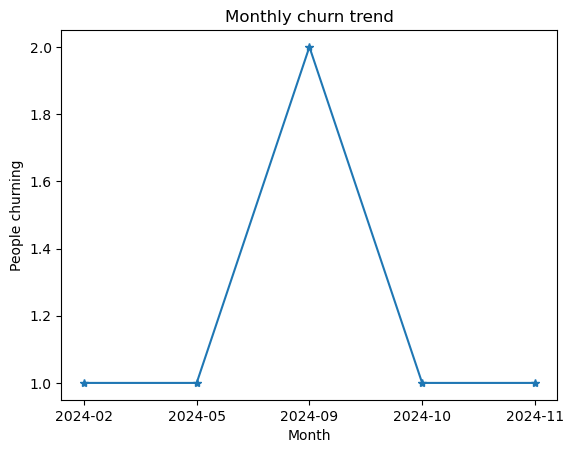

In [88]:
df_visual["cancellation_month"]=df["cancellation_date"].dt.to_period('M')
df_visual["cancellation_month"]

churn_trend=df_visual[df_visual["churn_flag"]==1].groupby('cancellation_month').size()

plt.plot(churn_trend.index.astype(str),churn_trend.values,marker='*')
plt.title("Monthly churn trend")
plt.xlabel("Month")
plt.ylabel("People churning")
plt.show()

In [ ]:
#Churn by plan type


<BarContainer object of 3 artists>

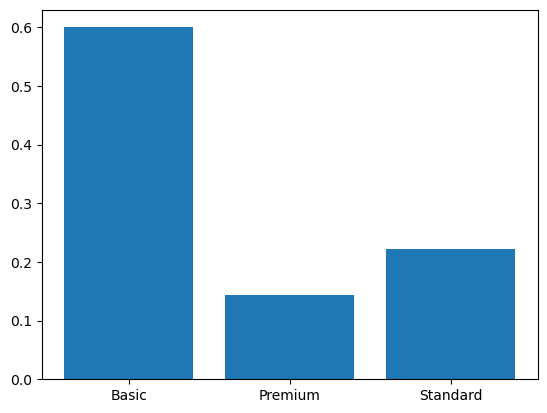

In [93]:
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
plt.bar(churn_plan.index,churn_plan.value)

In [101]:
import warnings
warnings.filterwarnings("ignore")

In [108]:
df["churn_risk"].unique()

array(['low', 'high', 'med'], dtype=object)

In [114]:
df_encoded = df_visual[["plan_type", "contract_type", "churn_score", "churn_flag", "churn_risk", "escalations"]].copy()
order_mappings={
    "plan_type":['Basic',"Standard","Premium"],
    "contract_type":["Monthly","Annual"],
    "churn_risk":["low","med","high"]
}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype("category"),categories=order,ordered=True).codes

df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,0


<Axes: >

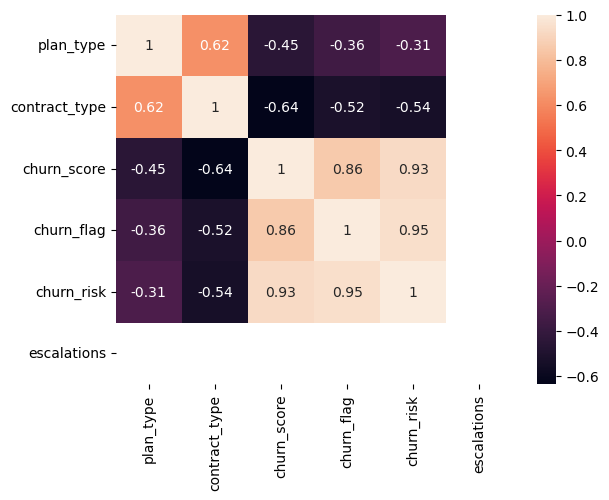

In [115]:
sns.heatmap(df_encoded.corr(),annot=True)

In [ ]:
churn_rate